In [ ]:
!pip install earthengine-api geemap rasterio xarray scikit-learn numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.6 MB/s eta 0:00:00


In [ ]:
import ee
import geemap

ee.Authenticate()
ee.Initialize(project='gro-oi')

In [ ]:
import ee

# Uttarakhand boundary
region = ee.FeatureCollection("FAO/GAUL/2015/level1") \
            .filter(ee.Filter.eq('ADM1_NAME','Uttarakhand'))

Map = geemap.Map()
Map.centerObject(region,7)
Map.addLayer(region,{},'Uttarakhand')
Map

Map(center=[30.123461938645715, 79.2002359634135], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
# Sentinel-2
sentinel = ee.ImageCollection("COPERNICUS/S2_SR") \
    .filterBounds(region) \
    .filterDate('2023-01-01','2023-12-31') \
    .select(['B4','B8']) \
    .median()

# DEM
dem = ee.Image("USGS/SRTMGL1_003")

# Weather ERA5-Land (Correct dataset)
era5 = ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR") \
    .filterDate('2023-01-01','2023-12-31') \
    .select(['temperature_2m','total_precipitation_sum'])

weather = era5.mean().rename([
    'mean_2m_air_temperature',
    'total_precipitation'
])

# Fire Data (VIIRS)
fire = ee.ImageCollection("FIRMS") \
    .filterBounds(region) \
    .filterDate('2023-01-01','2023-12-31')

fire_points = fire.map(lambda img: img.select('T21'))

In [ ]:
terrain = ee.Terrain.products(dem)

slope = terrain.select('slope')
aspect = terrain.select('aspect')

In [ ]:
ndvi = sentinel.normalizedDifference(['B8','B4']).rename('NDVI')

In [ ]:
feature_stack = ee.Image.cat([
    ndvi,
    slope,
    aspect,
    weather
]).clip(region)

Map.addLayer(ndvi, {'min':0, 'max':1, 'palette':['white','green']}, 'NDVI')
Map

Map(bottom=13806.0, center=[30.123461938645715, 79.2002359634135], controls=(WidgetControl(options=['position'…

In [ ]:
# VIIRS Fire dataset
fire = ee.ImageCollection("FIRMS") \
    .filterBounds(region) \
    .filterDate('2023-01-01','2023-12-31')

# Fire detection using brightness temperature
fire_mask = fire.select('T21').max().gt(330)

labels = fire_mask.rename('fire')

Map.addLayer(labels,{'min':0,'max':1},'Fire Labels')

In [ ]:
print(labels.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=region.geometry(),
    scale=1000,
    maxPixels=1e9
).getInfo())

{'fire': {'0': 5294.231372549021, '1': 315.3921568627451}}


In [ ]:
training = feature_stack.addBands(labels)

samples = training.stratifiedSample(
    numPoints=3000,
    classBand='fire',
    classValues=[0,1],
    classPoints=[1500,1500],
    region=region.geometry(),
    scale=30,
    geometries=True,
    #tileScale=4 (change this again when using tpu runtime)
    tileScale=4
)

print(samples.size().getInfo())

3000


In [ ]:
samples_no_geom = samples.select(
    ['NDVI','slope','aspect','mean_2m_air_temperature','total_precipitation','fire']
)

In [ ]:
import pandas as pd



data = geemap.ee_to_df(samples_no_geom)

data = data.dropna()
print(data.columns)
# X = data[['NDVI','slope','aspect','mean_2m_air_temperature','total_precipitation']]
# y = data['fire']

Index(['NDVI', 'aspect', 'fire', 'mean_2m_air_temperature', 'slope',
       'total_precipitation'],
      dtype='object')


In [ ]:
X = data[['NDVI','slope','aspect','mean_2m_air_temperature','total_precipitation']]
y = data['fire']

In [ ]:
print(data['fire'].value_counts())

fire
0    1500
1    1500
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.92      0.83      0.87       310
           1       0.83      0.92      0.88       290

    accuracy                           0.88       600
   macro avg       0.88      0.88      0.87       600
weighted avg       0.88      0.88      0.87       600



In [ ]:
classifier = ee.Classifier.smileRandomForest(200).train(
    features=samples,
    classProperty='fire',
    inputProperties=['NDVI','slope','aspect','mean_2m_air_temperature','total_precipitation']
)

prediction = feature_stack.classify(classifier)

Map.addLayer(prediction,
             {'min':0,'max':1,'palette':['green','red']},
             'Fire Probability')

Map

Map(bottom=13806.0, center=[30.123461938645715, 79.2002359634135], controls=(WidgetControl(options=['position'…

In [ ]:
task = ee.batch.Export.image.toDrive(
    image=prediction,
    description='fire_probability_map',
    scale=30,
    region=region.geometry(),
    maxPixels=1e13
)

task.start()

In [ ]:
print(task.status())

{'state': 'COMPLETED', 'description': 'fire_probability_map', 'priority': 100, 'creation_timestamp_ms': 1773059947096, 'update_timestamp_ms': 1773060886913, 'start_timestamp_ms': 1773059996614, 'task_type': 'EXPORT_IMAGE', 'destination_uris': ['https://drive.google.com/'], 'attempt': 1, 'batch_eecu_usage_seconds': 68947.6796875, 'id': 'MGP2SRXUWD5JZSXL4OOWF3NW', 'name': 'projects/gro-oi/operations/MGP2SRXUWD5JZSXL4OOWF3NW'}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

size = 100
grid = np.zeros((size,size))

# initial fire
grid[50,50] = 1

def spread_fire(grid,steps):

    for _ in range(steps):
        new_grid = grid.copy()

        for i in range(1,size-1):
            for j in range(1,size-1):

                if grid[i,j] == 1:

                    neighbors = [
                        (i+1,j),(i-1,j),
                        (i,j+1),(i,j-1)
                    ]

                    for n in neighbors:
                        if np.random.rand() < 0.4:
                            new_grid[n] = 1

        grid = new_grid

    return grid

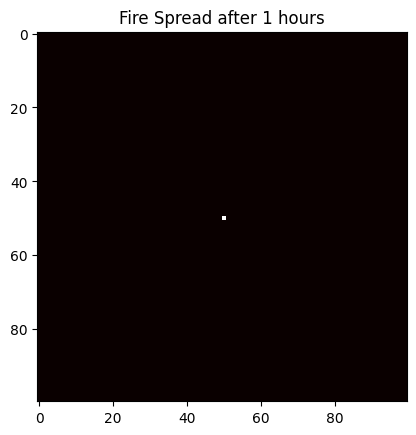

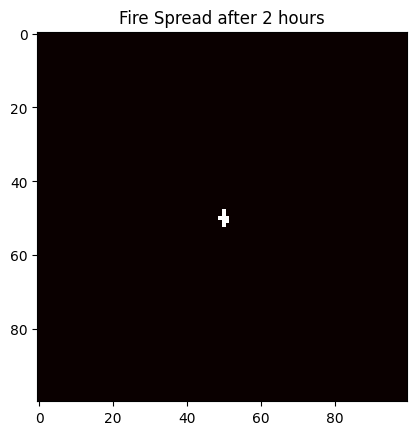

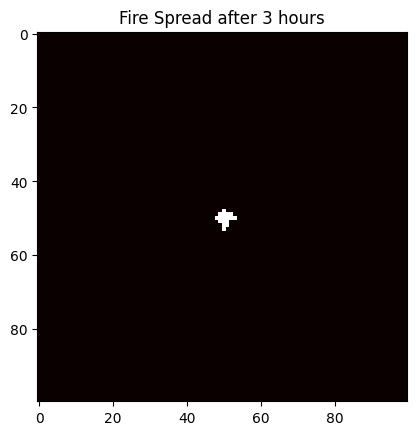

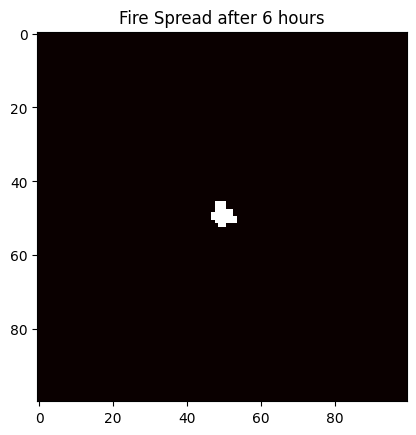

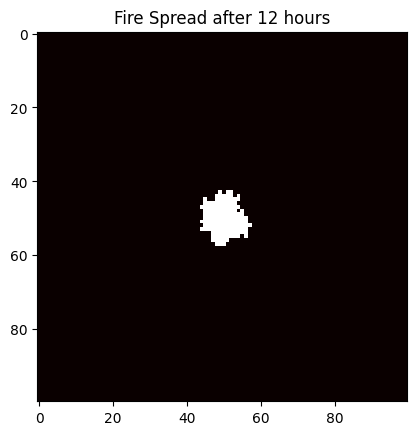

In [ ]:
times = [1,2,3,6,12]

for t in times:

    result = spread_fire(grid.copy(),t)

    plt.imshow(result,cmap='hot')
    plt.title(f'Fire Spread after {t} hours')
    plt.show()

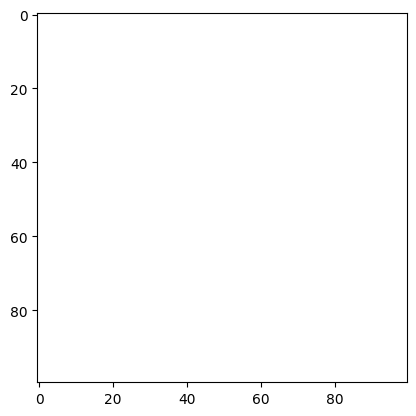

In [ ]:
import matplotlib.animation as animation

fig = plt.figure()

frames = []

grid = np.zeros((size,size))
grid[50,50] = 1

for i in range(20):

    grid = spread_fire(grid,1)

    frame = plt.imshow(grid,cmap='hot',animated=True)

    frames.append([frame])

ani = animation.ArtistAnimation(fig,frames,interval=200)

ani.save("fire_spread.gif")